uni_section_v3: validate_v9 초기 좌표/타겟 Mp + yj 고급 손실함수/커리큘럼 학습 통합

데이터: nodes=torch.Size([93, 8]) | edges=torch.Size([2, 176])

[ uni_section_v3 ] Training  |  Target Mp = 47,421,470 N·mm  |  Epochs: 181
  CGDN: hidden=128, layers=4, heads=4  |  Curriculum: True (0.1, 0.9)
Epoch ||  Loss  ||  Phys  |  Smth  |  Area  |  Mass  |  Coll  | Keepout
00000 || 48.9869 || 0.6868 | 0.3333 | 1162.9 | 0.0012 | 42.1189 | 0.0000
00019 || 73.7342 || 0.7836 | 0.0943 | 1284.4 | 0.0013 | 65.8986 | 0.0005
00039 || 46.4590 || 0.8832 | 0.0984 |  990.9 | 0.0010 | 37.6268 | 0.0000
00059 || 28.4730 || 0.8672 | 0.0914 | 1100.4 | 0.0011 | 19.7988 | 0.0000
00079 || 17.1948 || 0.8735 | 0.1701 |  967.3 | 0.0010 | 8.4535 | 0.0000
00099 || 25.9456 || 0.8742 | 0.1743 | 1037.1 | 0.0010 | 17.1935 | 0.0000
00119 || 21.0078 || 0.8745 | 0.1548 | 1019.7 | 0.0010 | 12.2509 | 0.0000
00139 || 31.8983 || 0.8752 | 0.0919 | 1034.3 | 0.0010 | 23.1378 | 0.0000
00159 || 23.1392 || 0.8659 | 0.0909 | 1083.5 | 0.0011 | 14.4713 | 0.0000


ValueError: x and y must have same first dimension, but have shapes (181,) and (0,)

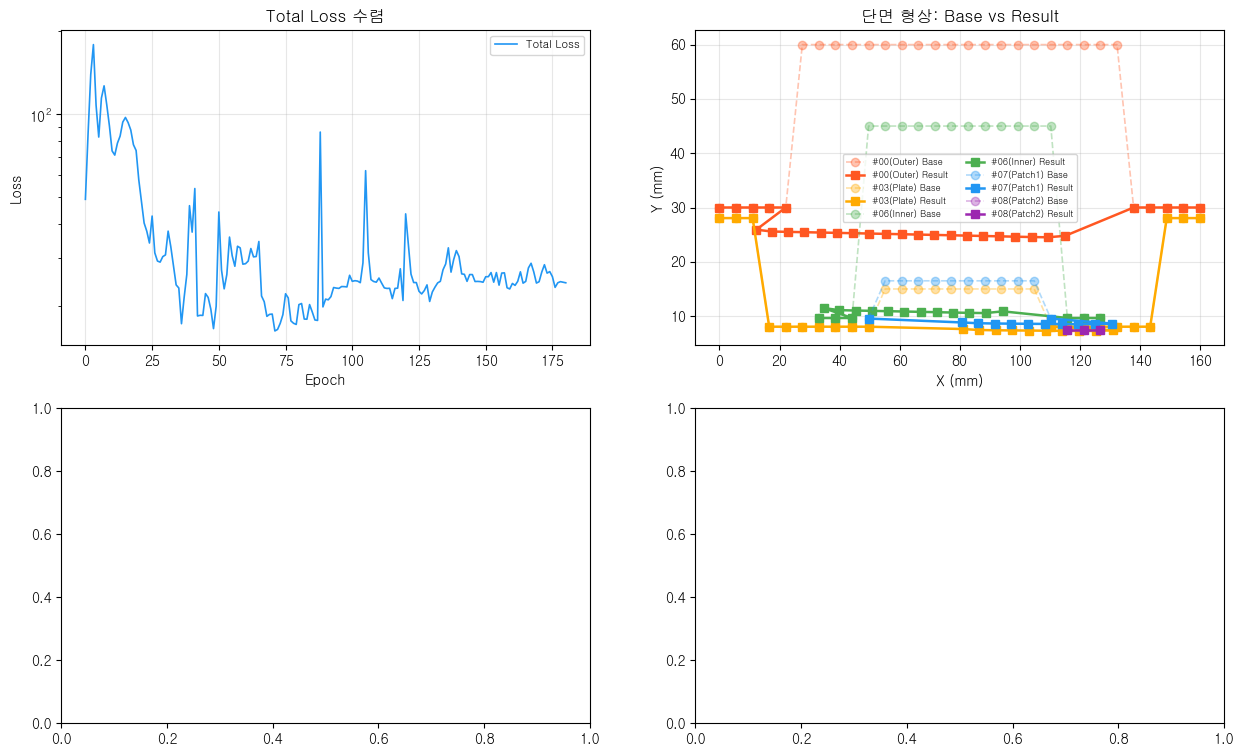

In [1]:
#!/usr/bin/env python
# coding: utf-8

"""
uni_section_v3.py
─────────────────────────────────────
pna_solver_validate_v9.py 의 단일 섹션(Single-section, B-Pillar 5 parts, 30 nodes/part)
초기 좌표 구성 + 타겟 전소성 모멘트(Mp) 설정을 100% 그대로 유지하면서,
20260401_yj.py 의 고급 손실함수 체계(Smoothness-angle, Mass, Collision v3, Keep-out)와
커리큘럼 학습 스케줄러를 이식한 버전.

command_v2.md 지시서 반영 사항:
  - Step 1: compute_smoothness_loss_angle / compute_mass_loss /
            compute_collision_loss_v3 / compute_repulsive_keepout_loss 이식
  - Step 2: get_curriculum_weights 이식 (단일 섹션이므로 continuity/shape 항 제외)
  - Step 3: weights 딕셔너리 기반 train_step 재구성
  - Step 4: 메인 실행부에 단일 섹션(0)용 keepout 영역 정의 추가
  - compute_section_continuity_loss / compute_shape_continuity_loss 는
    층간(섹션간) 연속성을 위한 함수이므로 단일 섹션 모델에서는 제외
"""

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Gulim'  # Windows 한글 폰트

from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# SECTION 0: ImplicitPNASolver + CGDN  (pna_solver_validate_v9.py 그대로 — 수정 없음)
# ══════════════════════════════════════════════════════════════════

def compute_edge_mp_pna(coords, t, fy, edge_index, n_iter=50):
    """
    Thick Edge (2D Plate) PNA 이분탐색 + Mp 계산
    엣지 두께를 Y축으로 투영하여 수평 엣지도 연속적으로 처리 → 평형 잔차 ≈ 0.
    Returns: (mp_total, y_pna)
    """
    mask = edge_index[0] < edge_index[1]
    u, v = edge_index[0][mask], edge_index[1][mask]

    y_u, y_v = coords[u, 1], coords[v, 1]
    x_u, x_v = coords[u, 0], coords[v, 0]
    L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
    t_e  = t[u].squeeze(-1)
    fy_e = fy[u].squeeze(-1)

    dx   = torch.abs(x_u - x_v)
    t_y  = t_e * (dx / (L + 1e-12))
    y_max = torch.maximum(y_u, y_v)
    y_min = torch.minimum(y_u, y_v)
    y_top = y_max + t_y / 2.0
    y_bot = y_min - t_y / 2.0
    H     = torch.clamp(y_top - y_bot, min=1e-12)

    Area_fy = L * t_e * fy_e

    with torch.no_grad():
        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna = 0.5 * (y_lo + y_hi)

    alpha        = torch.clamp((y_top - y_pna) / H, 0.0, 1.0)
    centroid_top = y_top - (alpha * H) / 2.0
    centroid_bot = y_bot + ((1.0 - alpha) * H) / 2.0
    m_top        = alpha * (centroid_top - y_pna)
    m_bot        = (1.0 - alpha) * (y_pna - centroid_bot)
    mp_total     = torch.sum(Area_fy * (m_top + m_bot))

    return mp_total, y_pna


class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    Forward : Edge-based 이분탐색으로 순 축력 = 0인 y_pna 탐색 (평형 잔차 ~1e-8)
    Backward: IFT + ∂Mp/∂y_pna = 0 (평형 조건) → y_pna 고정 하에서 직접 미분만 계산
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=40):
        mp_pred, y_pna = compute_edge_mp_pna(coords, t, fy, edge_index, n_iter)

        mask = edge_index[0] < edge_index[1]
        ctx.save_for_backward(coords, t, fy, y_pna.reshape(1), edge_index)
        ctx.mask = mask
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        mask = ctx.mask
        y_pna = y_pna_buf[0].detach()

        with torch.enable_grad():
            coords_g = coords.detach().requires_grad_(True)
            u, v = edge_index[0][mask], edge_index[1][mask]
            y_u, y_v = coords_g[u, 1], coords_g[v, 1]
            x_u, x_v = coords_g[u, 0], coords_g[v, 0]
            L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
            t_e  = t[u].squeeze(-1)
            fy_e = fy[u].squeeze(-1)

            dx_b   = torch.abs(x_u - x_v)
            t_y_b  = t_e * (dx_b / (L + 1e-12))
            y_max  = torch.maximum(y_u, y_v)
            y_min  = torch.minimum(y_u, y_v)
            y_top_b = y_max + t_y_b / 2.0
            y_bot_b = y_min - t_y_b / 2.0
            H_b     = torch.clamp(y_top_b - y_bot_b, min=1e-12)
            Area_fy_b = L * t_e * fy_e

            alpha_b      = torch.clamp((y_top_b - y_pna) / H_b, 0.0, 1.0)
            centroid_top_b = y_top_b - (alpha_b * H_b) / 2.0
            centroid_bot_b = y_bot_b + ((1.0 - alpha_b) * H_b) / 2.0
            m_top_b      = alpha_b * (centroid_top_b - y_pna)
            m_bot_b      = (1.0 - alpha_b) * (y_pna - centroid_bot_b)
            mp_direct    = torch.sum(Area_fy_b * (m_top_b + m_bot_b))

        (grad_coords,) = torch.autograd.grad(mp_direct, coords_g)
        return grad_coords * grad_output, None, None, None, None


def calculate_mpl(coords, t, fy, edge_index):
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)


class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden]"""
    MP_SCALE = 1e6

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM modulation → GELU → Residual  (AdaIN pattern)"""
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)
        h = gamma * h + beta
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network (v3)
    입력 노드 특징 (in_channels=8): [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    엣지 특징 (edge_dim=4): [길이, 각도, part_id, edge_type]
    """

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        delta_coords = self.decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)

        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)

        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        return new_coords, delta_coords


# ══════════════════════════════════════════════════════════════════
# SECTION 1: Loss Functions  (20260401_yj.py 에서 이식)
# ══════════════════════════════════════════════════════════════════
# 주의: compute_section_continuity_loss / compute_shape_continuity_loss 는
#       층(섹션)간 연속성을 위한 함수이므로 단일 섹션 모델에서는 이식하지 않음.

def compute_smoothness_loss_angle(new_coords, edge_index, edge_attr):
    """현재 각도만 고려해 노드별 좌우 엣지 각도 최소화 & 90도 미만 제한"""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)

    src = src[mask]
    dst = dst[mask]

    num_nodes = new_coords.shape[0]
    all_u = torch.cat([src, dst])
    all_v = torch.cat([dst, src])

    adj = [[] for _ in range(num_nodes)]
    for u, v in zip(all_u.tolist(), all_v.tolist()):
        adj[u].append(v)

    left_angles = []
    right_angles = []

    for node, neighbors in enumerate(adj):
        if len(neighbors) < 2:
            continue

        node_x = new_coords[node, 0]
        left_nodes = [n for n in neighbors if new_coords[n, 0] < node_x]
        right_nodes = [n for n in neighbors if new_coords[n, 0] > node_x]

        if len(left_nodes) != 1 or len(right_nodes) != 1:
            continue

        left_node = left_nodes[0]
        right_node = right_nodes[0]

        left_vec = new_coords[node] - new_coords[left_node]
        right_vec = new_coords[right_node] - new_coords[node]

        left_angles.append(torch.atan2(left_vec[1], left_vec[0]))
        right_angles.append(torch.atan2(right_vec[1], right_vec[0]))

    if len(left_angles) == 0:
        return torch.tensor(0.0, device=new_coords.device)

    left_angles = torch.stack(left_angles)
    right_angles = torch.stack(right_angles)

    results = 0.0

    angle_diff = (left_angles - right_angles + math.pi) % (2.0 * math.pi) - math.pi
    results += torch.mean(angle_diff.pow(2))

    max_rad = math.pi / 2.0
    left_violation = torch.relu(left_angles.abs() - max_rad)
    right_violation = torch.relu(right_angles.abs() - max_rad)
    results += torch.mean(left_violation.pow(2) + right_violation.pow(2))

    return results


def compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area=None):
    """총 질량(면적 근사) 계산. target_area가 주어지면 상대 오차 제곱 반환."""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src = src[mask]
    dst = dst[mask]

    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)

    if target_area is not None and target_area > 0:
        return area, torch.abs(area - target_area) / (target_area + 1e-12)
    else:
        return area, area * 1e-6


def compute_collision_loss_v3(new_coords, part_ids, section_ids, margin=2, parts_order_in_sections=None):
    """
    모든 섹션(section)과 파트(part)에 대해 일반화된 계층적 침투 방지 손실을 계산합니다.
    parts_order_in_sections: {section_id: [outer→inner part_id 순서]}
    """
    total_loss = torch.tensor(0.0, device=new_coords.device, requires_grad=True)

    unique_sections = torch.unique(section_ids)
    valid_pairs_count = 0

    def compute_segment_penetration_loss(coords_outer, coords_inner, normal_direction_CW, margin=0.01):
        if coords_outer.shape[0] < 2 or coords_inner.shape[0] == 0:
            return torch.tensor(0.0, device=coords_outer.device, requires_grad=True)

        A = coords_outer[:-1]
        B = coords_outer[1:]
        AB = B - A

        P = coords_inner.unsqueeze(1)
        A_exp = A.unsqueeze(0)
        AB_exp = AB.unsqueeze(0)

        AB_squared = torch.sum(AB_exp ** 2, dim=-1) + 1e-8
        AP = P - A_exp
        t = torch.sum(AP * AB_exp, dim=-1) / AB_squared

        valid_mask = (t >= 0.0) & (t <= 1.0)
        if valid_mask.sum() == 0:
            return torch.tensor(0.0, device=coords_outer.device, requires_grad=True)

        C = A_exp + t.unsqueeze(-1) * AB_exp

        tangent = AB_exp / (torch.norm(AB_exp, dim=-1, keepdim=True) + 1e-8)
        if normal_direction_CW == True:
            normal = torch.stack([tangent[..., 1], -tangent[..., 0]], dim=-1)
        elif normal_direction_CW == False:
            normal = torch.stack([-tangent[..., 1], tangent[..., 0]], dim=-1)
        else:
            raise ValueError("normal_direction_CW must be True (CW) or False (CCW)")

        normal = normal.expand(P.shape[0], -1, -1)

        CP = P - C
        projection = torch.sum(CP * normal, dim=-1)
        violation = torch.relu(margin - projection)
        violation = violation * valid_mask.float()

        return torch.sum(violation)

    for sec in unique_sections:
        sec_mask = (section_ids == sec)
        sec_parts = part_ids[sec_mask]

        full_order = torch.tensor(parts_order_in_sections[int(sec.item())], dtype=part_ids.dtype, device=part_ids.device)
        unique_parts = torch.unique(sec_parts)
        ordered_parts = full_order[torch.isin(full_order, unique_parts)]

        if len(ordered_parts) < 2:
            continue

        for i in range(len(ordered_parts) - 1):
            outer_part_id = ordered_parts[i]

            for j in range(i + 1, len(ordered_parts)):
                inner_part_id = ordered_parts[j]

                mask_outer = sec_mask & (part_ids == outer_part_id)
                mask_inner = sec_mask & (part_ids == inner_part_id)

                coords_outer = new_coords[mask_outer]
                coords_inner = new_coords[mask_inner]

                loss_outer_inner = compute_segment_penetration_loss(coords_outer, coords_inner, normal_direction_CW=True, margin=margin)
                total_loss = total_loss + loss_outer_inner
                valid_pairs_count += 1

                loss_inner_outer = compute_segment_penetration_loss(coords_inner, coords_outer, normal_direction_CW=False, margin=margin)
                total_loss = total_loss + loss_inner_outer
                valid_pairs_count += 1

    if valid_pairs_count > 0:
        total_loss = total_loss / valid_pairs_count

    return total_loss


def compute_repulsive_keepout_loss(new_coords, section_ids, keepout, height_multiplier=1.0):
    """가상의 자석(척력)을 이용해 노드를 설계 제한 영역(keep-out)에서 부드럽게 밀어내는 Loss."""
    total_repulsive_loss = torch.tensor(0.0, device=new_coords.device)

    if keepout is None:
        return total_repulsive_loss

    unique_sections = torch.unique(section_ids)

    for lvl in unique_sections:
        lvl_idx = int(lvl.item())
        if lvl_idx in keepout:
            mask = (section_ids == lvl)
            x = new_coords[mask, 0]
            y = new_coords[mask, 1]

            for kz in keepout[lvl_idx]:
                k_x1, k_x2, k_y1, k_y2 = kz
                k_xmin, k_xmax, k_ymin, k_ymax = min(k_x1, k_x2), max(k_x1, k_x2), min(k_y1, k_y2), max(k_y1, k_y2)

                center_x = (k_xmin + k_xmax) / 2.0
                center_y = (k_ymin + k_ymax) / 2.0
                radius_x = max((k_xmax - k_xmin) / 2.0, 1e-6)
                radius_y = max((k_ymax - k_ymin) / 2.0, 1e-6)

                in_box = (x > k_xmin) & (x < k_xmax) & (y > k_ymin) & (y < k_ymax)

                if in_box.any():
                    x_in = x[in_box]
                    y_in = y[in_box]

                    dist_x = abs((x_in - center_x) / radius_x)
                    dist_y = abs((y_in - center_y) / radius_y)

                    repulsion = torch.exp(-dist_x - dist_y + 0.5)

                    total_repulsive_loss += torch.sum(repulsion) * height_multiplier

    return total_repulsive_loss


# ══════════════════════════════════════════════════════════════════
# SECTION 2: 커리큘럼 학습 스케줄러  (20260401_yj.py get_curriculum_weights 이식)
# ══════════════════════════════════════════════════════════════════

def get_curriculum_weights(epoch, total_epochs, curriculum_ratio):
    """
    에폭 진행도에 따라 손실 함수의 가중치 multiplier(0→1)를 반환합니다.
    단일 섹션 모델이므로 continuity/shape 항은 제외하고
    (s_phys, s_smooth, s_mass, s_collision, s_keepout) 5개만 반환합니다.
    """
    phase1_epochs, phase3_epochs = 0, total_epochs
    progress = 1.0

    if curriculum_ratio[0] > 0.0:
        phase1_epochs = int(total_epochs * curriculum_ratio[0])
        if epoch < phase1_epochs:
            progress = 0.0

    if curriculum_ratio[1] > 0.0:
        phase3_epochs = int(total_epochs * curriculum_ratio[1])
        if epoch >= phase3_epochs:
            progress = 1.0

    if epoch >= phase1_epochs and epoch < phase3_epochs:
        x = (epoch - phase1_epochs) / max(phase3_epochs - phase1_epochs, 1)
        progress = 0.5 * (1 + math.sin(math.pi * (x - 0.5)))

    s_phys      = 1.0
    s_smooth    = progress
    s_mass      = progress
    s_collision = 1.0
    s_keepout   = progress
    return s_phys, s_smooth, s_mass, s_collision, s_keepout


# ══════════════════════════════════════════════════════════════════
# SECTION 3: Data Setup  (pna_solver_validate_v9.py build_bpillar_section 그대로 — 수정 없음)
# ══════════════════════════════════════════════════════════════════

def build_bpillar_section():
    """
    B-Pillar 5-Part 단면 (사용자 제공 도면의 X-비율 완벽 모사)
    initial 좌표 구성은 pna_solver_validate_v9.py 와 100% 동일하게 유지.
    """
    part_configs = [
        (0, 30.0, 2.30, 1470.0, True),   # #00 Outer Hat
        (1, 28.05, 1.60,  980.0, False), # #03 Inner Plate
        (2, 29.0, 1.60, 1470.0, True),   # #06 Inner Hat
        (3, 24.0, 1.40,  980.0, False),  # #07 Patch 1
        (4, 22.0, 1.60,  440.0, False),  # #08 Patch 2
    ]

    num_nodes   = 30
    total_width = 160.0
    dx          = total_width / (num_nodes - 1)

    nodes = []
    node_registry = {}
    idx = 0
    num_nodes_per_part = {}
    eps = 1e-3

    for part_id, y_base, t_val, fy_val, _ in part_configs:
        local_idx = 0
        for i in range(num_nodes):
            x_coord = i * dx
            x_ratio = x_coord / total_width

            if part_id == 2 and (x_ratio < 0.2 - eps or x_ratio > 0.8 + eps):
                continue
            if part_id == 3 and (x_ratio < 0.3 - eps or x_ratio > 0.7 + eps):
                continue
            if part_id == 4 and (x_ratio < 0.7 - eps or x_ratio > 0.8 + eps):
                continue

            fix = 0.0

            if part_id == 0:
                if x_ratio <= 0.1667 + eps or x_ratio >= 0.8333 - eps:
                    fix = 1.0
                    y_coord_node = 30.0
                else:
                    y_coord_node = 60.0

            elif part_id == 1:
                if x_ratio <= 0.0833 + eps or x_ratio >= 0.9167 - eps:
                    fix = 1.0
                    y_coord_node = 28.05
                elif (x_ratio >= 0.0833 + eps and x_ratio < 0.3334 - eps) or (x_ratio > 0.6666 + eps and x_ratio <= 0.9167 - eps):
                    fix = 1.0
                    y_coord_node = 8.05
                elif 0.3334 - eps <= x_ratio <= 0.6666 + eps:
                    y_coord_node = 15.0
                else:
                    y_coord_node = 8.05

            elif part_id == 2:
                if (x_ratio <= 0.3 - eps and x_ratio > 0.2 + eps) or (x_ratio >= 0.7 + eps and x_ratio < 0.8 - eps):
                    fix = 1.0
                    y_coord_node = 9.65
                else:
                    y_coord_node = 45.0

            elif part_id == 3:
                if (x_ratio <= 0.33 - eps and x_ratio > 0.3 + eps) or (x_ratio >= 0.67 + eps and x_ratio < 0.7 - eps):
                    fix = 1.0
                    y_coord_node = 9.55
                else:
                    y_coord_node = 16.5

            elif part_id == 4:
                fix = 1.0
                y_coord_node = 7.45

            nodes.append([x_coord, y_coord_node, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, local_idx)] = idx
            local_idx += 1
            idx += 1

        num_nodes_per_part[part_id] = local_idx

    x = torch.tensor(nodes, dtype=torch.float32)

    src_list, dst_list, edge_attr_list = [], [], []

    def add_edge(u, v, part_id):
        dx_val = x[v, 0] - x[u, 0]
        dy_val = x[v, 1] - x[u, 1]
        length = math.sqrt(dx_val**2 + dy_val**2)
        angle  = math.atan2(dy_val, dx_val)
        src_list.extend([u, v])
        dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0],
                               [length, -angle, float(part_id), 0.0]])

    for part_id, _, _, _, _ in part_configs:
        for i in range(num_nodes_per_part[part_id] - 1):
            u = node_registry[(part_id, i)]
            v = node_registry[(part_id, i + 1)]
            add_edge(u, v, part_id)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs), node_registry


def compute_y_pna_ref(coords, t, fy, edge_index, n_iter=50):
    """Thick Edge bisection으로 y_pna 계산 (검증용, validate_v9 그대로)"""
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        y_u, y_v = coords[u, 1], coords[v, 1]
        x_u, x_v = coords[u, 0], coords[v, 0]
        L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e  = t[u].squeeze(-1)
        fy_e = fy[u].squeeze(-1)

        dx   = torch.abs(x_u - x_v)
        t_y  = t_e * (dx / (L + 1e-12))
        y_max = torch.maximum(y_u, y_v)
        y_min = torch.minimum(y_u, y_v)
        y_top = y_max + t_y / 2.0
        y_bot = y_min - t_y / 2.0
        H     = torch.clamp(y_top - y_bot, min=1e-12)
        Area_fy = L * t_e * fy_e

        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        return 0.5 * (y_lo + y_hi)


def compute_section_area(coords, t, edge_index, part_ids=None):
    """단면 면적 계산: A = Σ(L × t_e) [mm²] (validate_v9 그대로)"""
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        x_u, y_u = coords[u, 0], coords[u, 1]
        x_v, y_v = coords[v, 0], coords[v, 1]
        L   = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e = t[u].squeeze(-1)
        area_e = L * t_e

        total_area = area_e.sum().item()

        per_part = {}
        if part_ids is not None:
            pid_e = part_ids[u]
            for pid in torch.unique(pid_e):
                per_part[int(pid.item())] = area_e[pid_e == pid].sum().item()

    return total_area, per_part


# ══════════════════════════════════════════════════════════════════
# SECTION 4: Training Step  (yj의 다목적 손실 + curriculum 을 단일 섹션에 적용)
# ══════════════════════════════════════════════════════════════════

def train_step(model, data, optimizer, target_mps, target_area, keepout,
               epoch, max_epochs, weights, curriculum,
               curriculum_ratio, parts_order_in_sections):
    """
    command_v2.md Step 3 반영:
    - weights 딕셔너리 기반 다목적 손실 합산
    - get_curriculum_weights 로 매 에폭 s_* multiplier 적용
    - compute_section_continuity_loss / compute_shape_continuity_loss 는 제외 (단일 섹션)
    """
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None

    fix_x_mask  = x[:, 2].bool().unsqueeze(1)
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    t           = x[:, 6].unsqueeze(1)
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    new_coords, delta_coords = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs
    )

    ## ── 층별(단일 섹션) 물리 손실 (L_phys) ──
    l_phys_total = torch.tensor(0.0, device=x.device)
    pred_mp_sections = []

    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t[section_mask]
        fy_section = fy[section_mask]

        src, dst = edge_index
        edge_mask = section_mask[src] & section_mask[dst]

        edge_type = edge_attr[:, 3]
        physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))

        edge_index_section = edge_index[:, physical_mask]

        local_index = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        local_index[section_mask] = torch.arange(section_mask.sum(), device=x.device)
        edge_index_section = local_index[edge_index_section]

        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, edge_index_section)

        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_section = abs((pred_mp_section - target_mp_section) / target_mp_section)
        l_phys_total += l_phys_section.squeeze()
        pred_mp_sections.append(pred_mp_section.item())

    num_sections = len(unique_sections)
    l_phys_total = torch.sqrt(l_phys_total) / num_sections
    pred_mp_sections = np.array(pred_mp_sections)

    ## ── 커리큘럼 가중치 (0→1 multiplier) ──
    s_phys, s_smooth, s_mass, s_collision, s_keepout = 1.0, 1.0, 1.0, 1.0, 1.0
    if curriculum:
        (s_phys, s_smooth, s_mass, s_collision, s_keepout
         ) = get_curriculum_weights(epoch, max_epochs, curriculum_ratio)

    ## ── 다목적 손실 계산 (Step 1 이식 함수) ──
    l_smooth     = compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area, l_mass = compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area)
    l_collision  = compute_collision_loss_v3(new_coords, part_ids, section_ids, parts_order_in_sections=parts_order_in_sections)
    l_keepout    = compute_repulsive_keepout_loss(new_coords, section_ids, keepout, height_multiplier=s_keepout)

    ## ── Total Loss ──
    loss = (weights['w_phys']      * l_phys_total * s_phys
          + weights['w_smooth']    * l_smooth     * s_smooth
          + weights['w_mass']      * l_mass       * s_mass
          + weights['w_collision'] * l_collision  * s_collision
          + weights['w_keepout']   * l_keepout    * s_keepout
          )

    loss.backward()
    optimizer.step()

    return {
        "loss":        loss.item(),
        "pred_mp":     pred_mp_sections,
        "l_phys":      l_phys_total.item(),
        "l_smooth":    l_smooth.item(),
        "area":        area.item(),
        "l_mass":      l_mass.item(),
        "l_collision": l_collision.item(),
        "l_keepout":   l_keepout.item(),
        "new_coords":  new_coords.detach(),
    }


def run_training(data, target_mps, target_area, keepout, parts_order_in_sections,
                  max_epochs=181, lr=1e-3, weights=None, curriculum=True,
                  curriculum_ratio=(0.1, 0.9), snapshot_interval=10):
    """
    pna_solver_validate_v9.py 의 run_training() 구조(snapshot 저장) +
    20260401_yj.py 의 다목적 손실/커리큘럼 train_step 결합.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data   = data.to(device)

    model = CGDN(
        in_channels=8,
        hidden_channels=128,
        num_layers=4,
        heads=4,
        edge_dim=4,
        max_displacement=50.0,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    if weights is None:
        weights = {
            'w_phys':      10.0,
            'w_smooth':    0.1,
            'w_mass':      0.01,
            'w_collision': 1.0,
            'w_keepout':   0.05,
        }

    x = data.x
    t_full  = x[:, 6:7].cpu()
    fy_full = x[:, 7:8].cpu()
    part_labels_t = x[:, 4].cpu().long()
    edge_index_cpu = data.edge_index.cpu()
    base_coords = x[:, :2].detach().cpu()

    history = {
        'loss':        [],
        'pred_mp':     [],
        'l_phys':      [],
        'l_smooth':    [],
        'area':        [],
        'l_mass':      [],
        'l_collision': [],
        'l_keepout':   [],
        'snapshots':   [],
    }

    print(f"\n{'=' * 65}")
    print(f"[ uni_section_v3 ] Training  |  Target Mp = {target_mps[0]:,.0f} N·mm  |  Epochs: {max_epochs}")
    print(f"  CGDN: hidden=128, layers=4, heads=4  |  Curriculum: {curriculum} {curriculum_ratio}")
    print(f"{'=' * 65}")
    print(f"Epoch ||  Loss  ||  Phys  |  Smth  |  Area  |  Mass  |  Coll  | Keepout")

    new_coords = None
    for epoch in range(max_epochs):
        info = train_step(model, data, optimizer, target_mps, target_area, keepout,
                           epoch, max_epochs, weights, curriculum,
                           curriculum_ratio, parts_order_in_sections)

        for key in ('loss', 'l_phys', 'l_smooth', 'area', 'l_mass', 'l_collision', 'l_keepout'):
            history[key].append(info[key])
        new_coords = info['new_coords']

        if epoch <= 10 or (epoch - 10) % 20 == 0:
            with torch.no_grad():
                snap_coords = new_coords.detach().cpu()
                snap_y_pna  = compute_y_pna_ref(snap_coords, t_full, fy_full, edge_index_cpu).item()
            history['snapshots'].append({
                'epoch':   epoch,
                'coords':  snap_coords,
                'y_pna':   snap_y_pna,
                'pred_mp': float(np.sum(info['pred_mp'])),
            })

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"{epoch:05d} || {info['loss']:.4f} || {info['l_phys']:.4f} | "
                  f"{info['l_smooth']:.4f} | {info['area']:6.1f} | "
                  f"{info['l_mass']:.4f} | {info['l_collision']:.4f} | "
                  f"{info['l_keepout']:.4f}")

    final_new_coords = new_coords.detach().cpu() if new_coords is not None else base_coords
    return history, base_coords, final_new_coords, part_labels_t


# ══════════════════════════════════════════════════════════════════
# SECTION 5: 시각화 (pna_solver_validate_v9.py 스타일 재사용)
# ══════════════════════════════════════════════════════════════════

def visualize_training(history, base_coords, result_coords, target_mp_val, part_labels=None):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes = axes.flatten()
    epochs = list(range(len(history['loss'])))

    ax = axes[0]
    ax.plot(epochs, history['loss'], color='#2196F3', linewidth=1.2, label='Total Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Total Loss 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[1]
    base_np = base_coords.numpy()
    result_np = result_coords.numpy()
    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
    pl = part_labels.numpy() if part_labels is not None else None
    for part_id in range(5):
        mask = (pl == part_id) if pl is not None else slice(None)
        c = part_colors[part_id]
        name = part_names[part_id]
        ax.plot(base_np[mask, 0], base_np[mask, 1], 'o--', color=c, alpha=0.35, linewidth=1.2, label=f'{name} Base')
        ax.plot(result_np[mask, 0], result_np[mask, 1], 's-', color=c, alpha=1.0, linewidth=1.8, label=f'{name} Result')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base vs Result', fontweight='bold')
    ax.legend(loc='best', fontsize=6.5, ncol=2)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    pred_mp_total = [float(np.sum(v)) for v in history['pred_mp']]
    ax.plot(epochs, [v / 1e6 for v in pred_mp_total], color='#2196F3', linewidth=1.2, label='Pred Mp')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', linestyle=':', linewidth=2.0, label='Target Mp')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp (MN·mm)')
    ax.set_title('Mp 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[3]
    ax.plot(epochs, history['l_smooth'], label='Smooth', linewidth=1.0)
    ax.plot(epochs, history['l_mass'], label='Mass', linewidth=1.0)
    ax.plot(epochs, history['l_collision'], label='Collision', linewidth=1.0)
    ax.plot(epochs, history['l_keepout'], label='Keepout', linewidth=1.0)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss term')
    ax.set_title('보조 손실 항 추이', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    plt.suptitle('uni_section_v3 학습 결과  |  B-Pillar 5 Parts', fontsize=13, fontweight='bold')
    plt.tight_layout()
    out_path = 'uni-section/uni_section_v3_result.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    print("uni_section_v3: validate_v9 초기 좌표/타겟 Mp + yj 고급 손실함수/커리큘럼 학습 통합")

    data, node_registry = build_bpillar_section()
    print(f"\n데이터: nodes={data.x.shape} | edges={data.edge_index.shape}")

    ## ── initial 좌표 구성과 타겟 전소성 모멘트는 validation_v9 설정 유지 ──
    TARGET_MP = 47_421_470  # N·mm (validate_v9 그대로)
    target_mps = {0: TARGET_MP}

    ## Step 4: 단일 섹션(0)에 대한 Keep-out 영역 정의
    ## build_bpillar_section() 좌표 범위(X: 0~160, Y: 약 0~60mm) 내부에 위치하도록 설정
    keepout = {
        0: [(50.0, 110.0, 32.0, 50.0)],
    }

    ## 계층 순서: 체크포인트 지침에 따라 단일 섹션 리스트 {0: [...]} 형태로 전달
    parts_order_in_sections = {
        0: [0, 2, 1, 3, 4],
    }

    weights = {
        'w_phys':      10.0,
        'w_smooth':    0.1,
        'w_mass':      0.01,
        'w_collision': 1.0,
        'w_keepout':   0.05,
    }

    history, base_coords, result_coords, part_labels = run_training(
        data,
        target_mps=target_mps,
        target_area=None,          # 초기 질량 보존이 필요하면 초기 area 값을 대입
        keepout=keepout,
        parts_order_in_sections=parts_order_in_sections,
        max_epochs=181,
        lr=1e-3,
        weights=weights,
        curriculum=True,
        curriculum_ratio=(0.1, 0.9),
        snapshot_interval=10,
    )

    visualize_training(history, base_coords, result_coords, TARGET_MP, part_labels=part_labels)

    final_pred = float(np.sum(history['pred_mp'][-1]))
    final_err  = abs(final_pred - TARGET_MP) / TARGET_MP * 100
    print(f"\n{'=' * 65}")
    print(f"최종 결과 요약")
    print(f"  Target Mp     : {TARGET_MP:>14,.0f} N·mm")
    print(f"  Final pred_mp : {final_pred:>14,.0f} N·mm")
    print(f"  Final Error   : {final_err:>6.2f}%")
    print(f"{'=' * 65}")
